# Hyperparameter Optimization: `label_dropout`

Sweeps `label_dropout` ∈ {0.5, 0.4, 0.3, 0.2} (0.1 already trained).

Each value is trained **from scratch for 20 epochs**, then evaluated via autoregressive rollout (10 steps, 10-member ensemble). Only **RMSE** and **SSR** are reported, averaged over 20 validation starting points.

## 1. Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from natsort import natsorted
import matplotlib.pyplot as plt

SQG_DIR = Path('SQG')
sys.path.insert(0, str(SQG_DIR))

from diffusion_networks import SongUNet
from dataset import SQGPairDataset, DATA_1H
from autoregressive_forecasting import (
    autoregressive_ensemble_rollout,
    compute_rmse,
    compute_ssr,
)

## 2. Shared Config

In [2]:
# ── data / model ──────────────────────────────────────────────────────────
DATA_STD       = 2660.0
IMG_CHANNELS   = 2
IMG_RESOLUTION = 64
FILTERS        = 32

# ── training ──────────────────────────────────────────────────────────────
BATCH_SIZE   = 16
NUM_EPOCHS   = 20
LR           = 1e-3
WEIGHT_DECAY = 1e-4
TRAIN_FRAC   = 0.8

# ── evaluation ────────────────────────────────────────────────────────────
ROLLOUT_STEPS = 10
N_ENSEMBLE    = 10
ODE_STEPS     = 100
N_INIT        = 20

# label_dropout=0.1 already trained — sweep remaining values high → low
LABEL_DROPOUT_VALUES = [0.5, 0.4, 0.3, 0.2]

SAVE_DIR = Path('../models')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Sweeping label_dropout: {LABEL_DROPOUT_VALUES}')

Device: cuda
Sweeping label_dropout: [0.5, 0.4, 0.3, 0.2]


## 3. Dataset + Validation Trajectories

Load once and reuse across all runs.

In [3]:
# Pair datasets for training / validation loss
train_dataset = SQGPairDataset(DATA_1H, std=DATA_STD, split='train')
val_dataset   = SQGPairDataset(DATA_1H, std=DATA_STD, split='val')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Pairs — train: {len(train_dataset)}, val: {len(val_dataset)}')

# Full trajectories for autoregressive rollout evaluation
files     = natsorted(DATA_1H.glob('sqg_N64_*hrly_*.npy'))
cut       = int(len(files) * TRAIN_FRAC)
val_files = files[cut:]

val_trajs = []
for f in val_files:
    arr = torch.tensor(np.load(f).astype(np.float32) / DATA_STD)  # (T, C, H, W)
    val_trajs.append(arr)

T_per_traj = val_trajs[0].shape[0]
print(f'Val trajectories: {len(val_trajs)},  timesteps per traj: {T_per_traj}')

# Fixed init points shared across all label_dropout runs
max_t        = T_per_traj - ROLLOUT_STEPS - 1
rng          = np.random.default_rng(42)
traj_indices = rng.integers(0, len(val_trajs), size=N_INIT)
time_indices = rng.integers(0, max_t,          size=N_INIT)
init_points  = list(zip(traj_indices.tolist(), time_indices.tolist()))
print(f'Init points: {N_INIT}')

Pairs — train: 8000, val: 2000
Val trajectories: 20,  timesteps per traj: 101
Init points: 20


## 4. Training Helper

`flow_matching_loss` and `train_one_run` are defined once and called for each `label_dropout` value.

In [4]:
def flow_matching_loss(model, x_t, x_t1):
    B         = x_t1.shape[0]
    s         = torch.rand(B, device=x_t1.device)
    s_spatial = s.view(B, 1, 1, 1)
    z0        = torch.randn_like(x_t1)
    z_s       = (1 - s_spatial) * z0 + s_spatial * x_t1
    target    = x_t1 - z0
    pred      = model(z_s, s, class_labels=x_t)
    return ((pred - target) ** 2).mean()


def train_one_run(label_dropout):
    """
    Train a fresh model with the given label_dropout for NUM_EPOCHS.
    Saves best checkpoint, then evaluates autoregressive rollout.

    Returns:
        (mean_rmse, mean_ssr) — np.ndarray of shape (ROLLOUT_STEPS,)
    """
    save_path = SAVE_DIR / f'best_model_ld{label_dropout:.2f}.pth'

    # fresh model — retrain from scratch
    model = SongUNet(
        img_resolution=IMG_RESOLUTION,
        in_channels=IMG_CHANNELS * 2,
        out_channels=IMG_CHANNELS,
        embedding_type='fourier',
        encoder_type='residual',
        decoder_type='standard',
        channel_mult_noise=2,
        resample_filter=[1, 3, 3, 1],
        model_channels=FILTERS,
        channel_mult=[2, 2, 2],
        attn_resolutions=[32],
        label_dropout=label_dropout,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    warmup    = optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, end_factor=1.0, total_iters=500
    )

    best_val = float('inf')

    for epoch in range(NUM_EPOCHS):
        # training
        model.train()
        total_train = 0.0
        for x_t, x_t1 in tqdm(train_loader,
                               desc=f'  ld={label_dropout:.2f}  E{epoch+1:02d}/{NUM_EPOCHS}',
                               leave=False):
            x_t  = x_t.to(device)
            x_t1 = x_t1.to(device)
            optimizer.zero_grad()
            loss = flow_matching_loss(model, x_t, x_t1)
            loss.backward()
            optimizer.step()
            warmup.step()
            total_train += loss.item()
        avg_train = total_train / len(train_loader)

        # validation
        model.eval()
        total_val = 0.0
        with torch.no_grad():
            for x_t, x_t1 in val_loader:
                x_t  = x_t.to(device)
                x_t1 = x_t1.to(device)
                total_val += flow_matching_loss(model, x_t, x_t1).item()
        avg_val = total_val / len(val_loader)

        scheduler.step()

        if avg_val < best_val:
            best_val = avg_val
            torch.save(model.state_dict(), save_path)
            tag = '  <- best'
        else:
            tag = ''

        print(f'  ld={label_dropout:.2f}  epoch {epoch+1:2d}/{NUM_EPOCHS}'
              f'  train={avg_train:.4f}  val={avg_val:.4f}{tag}')

    # ── evaluation ────────────────────────────────────────────────────────
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()

    all_rmse, all_ssr = [], []
    for ti, t in tqdm(init_points, desc=f'  Evaluating ld={label_dropout:.2f}', leave=False):
        x0    = val_trajs[ti][t]
        truth = val_trajs[ti][t + 1 : t + 1 + ROLLOUT_STEPS].numpy()

        preds      = autoregressive_ensemble_rollout(
            model, x0, ROLLOUT_STEPS, N_ENSEMBLE, ODE_STEPS, device=device
        )  # (steps, n_ens, C, H, W)
        preds_mean = preds.mean(axis=1)

        rmse = compute_rmse(preds_mean, truth)
        ssr  = compute_ssr(preds, rmse)

        all_rmse.append(rmse)
        all_ssr.append(ssr)

    mean_rmse = np.stack(all_rmse).mean(axis=0)  # (ROLLOUT_STEPS,)
    mean_ssr  = np.stack(all_ssr).mean(axis=0)

    print(f'\n  Results for label_dropout={label_dropout:.2f}:')
    print(f'  {"Lead":>5}  {"RMSE":>8}  {"SSR":>8}')
    for step, (r, s) in enumerate(zip(mean_rmse, mean_ssr), 1):
        print(f'  {step:5d}  {r:8.4f}  {s:8.4f}')

    return mean_rmse, mean_ssr

## 5. Run the Sweep

In [5]:
results    = {}
lead_times = np.arange(1, ROLLOUT_STEPS + 1)

for ld in LABEL_DROPOUT_VALUES:
    print(f'\n{"="*60}')
    print(f'Training  label_dropout = {ld}')
    print(f'{"="*60}')
    rmse, ssr = train_one_run(ld)
    results[ld] = {'rmse': rmse, 'ssr': ssr}

print('\nSweep complete.')


Training  label_dropout = 0.5


  ld=0.50  epoch  1/20  train=0.7555  val=0.1609  <- best


  ld=0.50  epoch  2/20  train=0.4333  val=0.0922  <- best


  ld=0.50  epoch  3/20  train=0.4192  val=0.0753  <- best


  ld=0.50  epoch  4/20  train=0.3976  val=0.0777


...

  ld=0.20  epoch 17/20  train=0.1669  val=0.0330


  ld=0.20  epoch 18/20  train=0.1747  val=0.0321


  ld=0.20  epoch 19/20  train=0.1679  val=0.0273  <- best


  ld=0.20  epoch 20/20  train=0.1649  val=0.0265  <- best



  Results for label_dropout=0.20:
   Lead      RMSE       SSR
      1    0.0235    0.8771
      2    0.0386    0.7183
      3    0.0500    0.6544
      4    0.0597    0.6195
      5    0.0689    0.5913
      6    0.0777    0.5680
      7    0.0865    0.5487
      8    0.0959    0.5294
      9    0.1057    0.5119
     10    0.1158    0.4951

Sweep complete.


## 6. Summary Table

In [6]:
# Full per-lead table
header = f'{"ld":<6}' + ''.join(f'  RMSE@{t:<2d}   SSR@{t:<2d}' for t in lead_times)
print(header)
print('-' * len(header))
for ld, res in sorted(results.items(), reverse=True):
    row = f'{ld:<6.2f}'
    for r, s in zip(res['rmse'], res['ssr']):
        row += f'  {r:8.4f}  {s:8.4f}'
    print(row)

# Lead-1 and lead-5 quick-look
print('\nLead-1 / Lead-5 summary:')
print(f'{"ld":<6}  {"RMSE@1":>8}  {"SSR@1":>8}  {"RMSE@5":>8}  {"SSR@5":>8}')
for ld, res in sorted(results.items(), reverse=True):
    r1, s1 = res['rmse'][0], res['ssr'][0]
    r5, s5 = res['rmse'][4], res['ssr'][4]
    print(f'{ld:<6.2f}  {r1:8.4f}  {s1:8.4f}  {r5:8.4f}  {s5:8.4f}')

ld      RMSE@1    SSR@1   RMSE@2    SSR@2   RMSE@3    SSR@3   RMSE@4    SSR@4   RMSE@5    SSR@5   RMSE@6    SSR@6   RMSE@7    SSR@7   RMSE@8    SSR@8   RMSE@9    SSR@9   RMSE@10   SSR@10
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0.50      0.0265    0.8866    0.0433    0.7333    0.0564    0.6653    0.0675    0.6261    0.0779    0.5992    0.0880    0.5804    0.0982    0.5634    0.1089    0.5468    0.1201    0.5299    0.1318    0.5159
0.40      0.0266    0.8798    0.0439    0.7091    0.0576    0.6463    0.0697    0.6047    0.0814    0.5768    0.0932    0.5530    0.1055    0.5290    0.1188    0.5063    0.1328    0.4870    0.1477    0.4686
0.30      0.0244    0.8677    0.0398    0.7166    0.0516    0.6498    0.0616    0.6145    0.0709    0.5893    0.0799    0.5686    0.0889    0.5509    0.0983    0.5329    0.1082    0.5149    0.1186    0.4981
0.20 

## 7. Comparison Plots

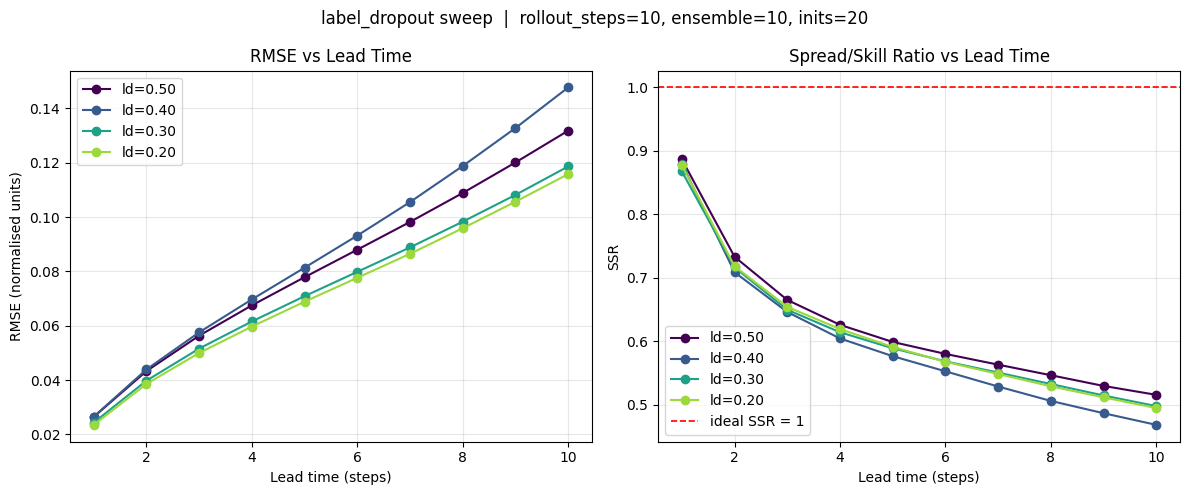

In [7]:
colors = plt.cm.viridis(np.linspace(0, 0.85, len(results)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for (ld, res), color in zip(sorted(results.items(), reverse=True), colors):
    ax1.plot(lead_times, res['rmse'], marker='o', label=f'ld={ld:.2f}', color=color)
    ax2.plot(lead_times, res['ssr'],  marker='o', label=f'ld={ld:.2f}', color=color)

ax1.set_xlabel('Lead time (steps)')
ax1.set_ylabel('RMSE (normalised units)')
ax1.set_title('RMSE vs Lead Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='ideal SSR = 1')
ax2.set_xlabel('Lead time (steps)')
ax2.set_ylabel('SSR')
ax2.set_title('Spread/Skill Ratio vs Lead Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(
    f'label_dropout sweep  |  rollout_steps={ROLLOUT_STEPS}, '
    f'ensemble={N_ENSEMBLE}, inits={N_INIT}',
    fontsize=12,
)
plt.tight_layout()
plt.show()